# 확률분포와 손실 함수의 MLE 해석

정규분포와 베르누이분포를 시각화하고, MSE와 Cross-Entropy가 각각의 확률 모형에서 최대우도추정(MLE)과 연결되는 과정을 유도한다. 모든 실험은 seed 42로 재현한다.

In [1]:
from io import BytesIO
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.probability import (
    plot_bernoulli_distributions,
    plot_normal_distributions,
    softmax,
)

np.random.seed(42)

## 확률 분포 시각화

- 정규분포: $\mathcal{N}(0,1)$과 $\mathcal{N}(2,0.5)$의 PDF를 같은 축에서 비교한다. 두 번째 표기의 0.5는 표준편차다.
- 베르누이분포: $B(0.3)$과 $B(0.7)$의 $x\in\{0,1\}$ PMF를 같은 축에서 비교한다.

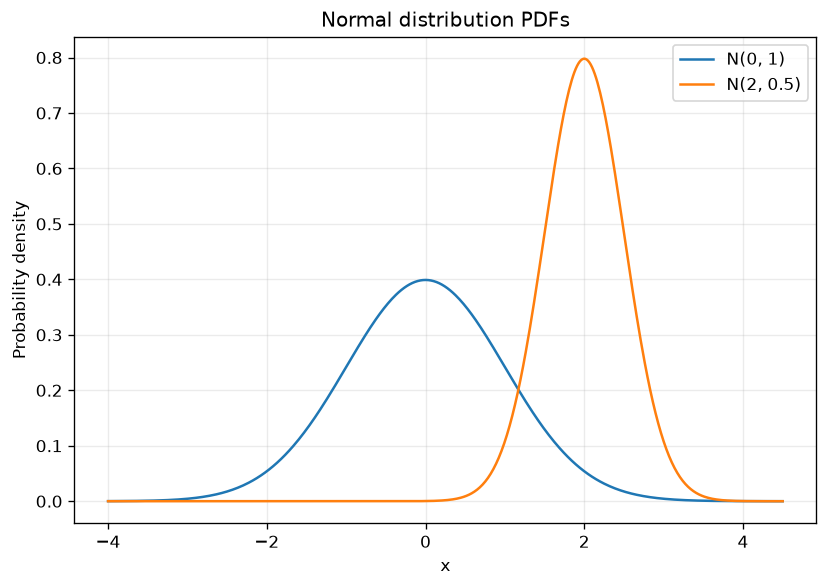

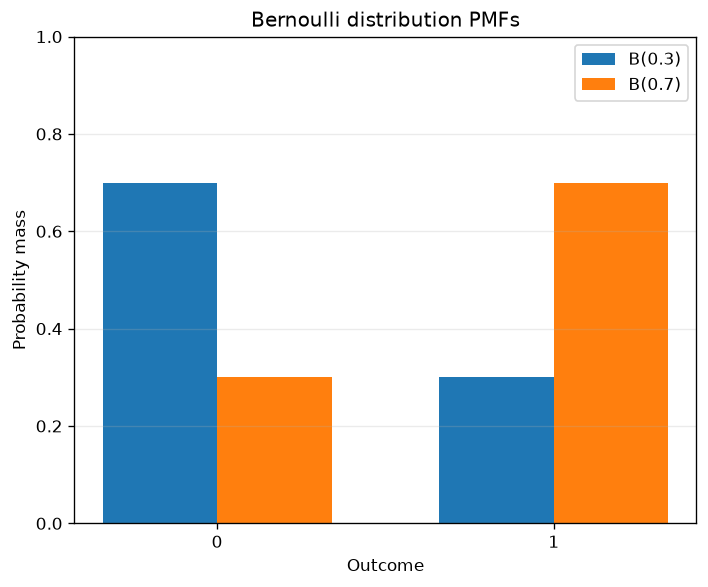

In [2]:
def display_figure(figure):
    buffer = BytesIO()
    figure.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

normal_figure, _ = plot_normal_distributions()
display_figure(normal_figure)
bernoulli_figure, _ = plot_bernoulli_distributions()
display_figure(bernoulli_figure)

## Softmax 검증

$\mathrm{softmax}(z_i)=\exp(z_i-\max(z))/\sum_j\exp(z_j-\max(z))$로 계산하면 큰 logit에서도 overflow를 막으면서 결과 합을 1로 유지한다.

In [3]:
logits = np.array([1000.0, 1001.0, 1002.0])
probabilities = softmax(logits)
print('softmax =', np.round(probabilities, 6))
print('sum =', probabilities.sum())
assert abs(probabilities.sum() - 1.0) <= 1e-6

softmax = [0.090031 0.244728 0.665241]
sum = 0.9999999999999999


## MSE 최소화 = 정규분포 가정 아래 MLE

회귀 오차를 독립인 정규 잡음으로 가정한다.
$$y_i=f(x_i)+\epsilon_i,\qquad \epsilon_i\sim\mathcal{N}(0,\sigma^2)$$
따라서 조건부 밀도와 전체 likelihood는
$$p(y_i\mid x_i)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y_i-f(x_i))^2}{2\sigma^2}\right],\qquad \mathcal{L}=\prod_{i=1}^{n}p(y_i\mid x_i).$$
곱을 합으로 바꾸기 위해 로그를 취하고 부호를 바꾸면
$$-\log\mathcal{L}=\frac{1}{2\sigma^2}\sum_i(y_i-f(x_i))^2+\frac{n}{2}\log(2\pi\sigma^2).$$
$\sigma^2$가 고정이면 두 번째 항과 양의 배율 $1/(2\sigma^2)$은 모델 파라미터에 무관하다. 그러므로
$$\arg\max\mathcal{L}=\arg\min\sum_i(y_i-f(x_i))^2=\arg\min\mathrm{MSE}.$$
즉 MSE 최소화는 일정한 분산의 정규 오차 모형에서 MLE와 같은 해를 갖는다.

## Binary Cross-Entropy 최소화 = 베르누이 MLE

$y_i\in\{0,1\}$이고 모델이 $p_i=P(y_i=1\mid x_i)$를 출력한다고 하자. 베르누이 likelihood는
$$\mathcal{L}=\prod_i p_i^{y_i}(1-p_i)^{1-y_i}.$$
Negative log-likelihood는
$$-\log\mathcal{L}=-\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].$$
이는 표본별 BCE의 합이다. 평균을 취하는 것은 양의 상수 $1/n$을 곱할 뿐이므로 최적해가 같고, BCE 최소화는 베르누이 MLE와 동일하다.

## Multiclass Cross-Entropy 최소화 = 카테고리 MLE

클래스 $c=1,\ldots,C$의 one-hot 정답을 $y_{ic}$, Softmax 확률을 $p_{ic}$라 하면 $\sum_c p_{ic}=1$이고 카테고리 likelihood는
$$\mathcal{L}=\prod_i\prod_c p_{ic}^{y_{ic}}.$$
따라서
$$-\log\mathcal{L}=-\sum_i\sum_c y_{ic}\log p_{ic},$$
즉 multiclass Cross-Entropy의 합이다. Cross-Entropy 최소화는 카테고리 분포의 관측 정답에 최대 확률을 부여하는 MLE다.